In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import sys
import os
import torch
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from matplotlib.colors import BoundaryNorm
import scienceplots
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import ConcatDataset

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [26]:
from src.trainer.IntervalTrainer import IntervalTrainer
from src.trainer.SimpleTrainer import SimpleTrainer
from src.data_utils import get_mnist_tasks, _extract_targets, get_context_sets
from src import models
from src.regulariser.UnbiasRegulariser import UnbiasRegulariser
from src.regulariser.MultiRegulariser import MultiRegulariser
from src.regulariser.L2Regulariser import L2Regulariser
import src.plotting_style as plotting_style

In [27]:
n_classes = 6
radius = 10
angles = np.linspace(0, 2 * np.pi, n_classes, endpoint=False)
centers = [(radius * np.cos(angle), radius * np.sin(angle)) for angle in angles]
X, y = sklearn.datasets.make_blobs(
    n_samples=2000, centers=centers, random_state=42, cluster_std=1.5
)
X, y = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

context_sets = [[0, 1], [2, 3], [4, 5]]
train_tasks = []
val_tasks = []
test_tasks = []
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
for class_1, class_2 in context_sets:
    mask = (y == class_1) | (y == class_2)
    X_pair, y_pair = X[mask], y[mask]

    X_train_temp, X_val_test, y_train_temp, y_val_test = train_test_split(
        X_pair,
        y_pair,
        test_size=(val_ratio + test_ratio),
        random_state=42,
        stratify=y_pair,
    )

    test_size_for_val_test_split = test_ratio / (val_ratio + test_ratio)

    X_val, X_test, y_val, y_test = train_test_split(
        X_val_test,
        y_val_test,
        test_size=test_size_for_val_test_split,
        random_state=42,
        stratify=y_val_test,
    )

    train_tasks.append(torch.utils.data.TensorDataset(X_train_temp, y_train_temp))
    val_tasks.append(torch.utils.data.TensorDataset(X_val, y_val))
    test_tasks.append(torch.utils.data.TensorDataset(X_test, y_test))

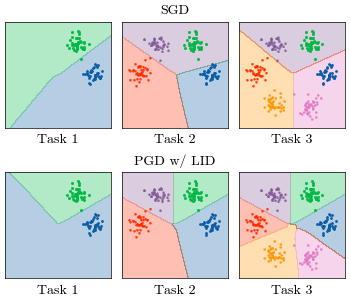

In [43]:
plt.style.use(["science", "no-latex", "scatter"])


def color(i: int):
    if i == 5:
        return "tab:pink"
    if i == 2:
        return "C4"
    if i == 4:
        return "C2"
    return f"C{i}"


@torch.no_grad()
def plot_results(sgd_models, certified_models, tasks):
    fig, axs = plt.subplots(
        2,
        3,
        gridspec_kw={"hspace": 0.1, "wspace": 0.1},
        # width_ratios=[1, 1, 1, 0.05, 1, 1, 1],
    )
    # axs[3].axis("off")
    gridsize = 500
    n_samples = 80

    x_min, x_max = -radius - 5, radius + 5
    y_min, y_max = -radius - 5, radius + 5

    colors = mcolors.ListedColormap([color(i) for i in range(n_classes)])

    for task_idx, task in enumerate(tasks):
        # Get the data for this task
        task_X, task_y = [], []
        for i in range(task_idx + 1):
            task_X_i, task_y_i = tasks[i].tensors
            task_X.append(task_X_i[:n_samples])
            task_y.append(task_y_i[:n_samples])
        task_X = torch.cat(task_X, dim=0)
        task_y = torch.cat(task_y, dim=0)

        # Get the classes for this task
        classes = context_sets[: task_idx + 1]

        for model_idx, model_set in enumerate([sgd_models, certified_models]):
            # Use the model after training on this task
            model = model_set[task_idx]
            # ax = axs[4 * model_idx + task_idx]
            ax = axs[model_idx][task_idx]
            ax.set_box_aspect(1)

            # Plot decision boundary
            xx, yy = torch.meshgrid(
                torch.linspace(x_min, x_max, gridsize),
                torch.linspace(y_min, y_max, gridsize),
            )
            mask = -torch.inf * torch.ones(n_classes)
            for class_ in classes:
                mask[class_] *= -1

            with torch.no_grad():
                grid_points = torch.stack((xx.ravel(), yy.ravel()), dim=1)
                Z = model(grid_points).clamp_(max=mask).argmax(dim=1).reshape(xx.shape)

            boundaries = np.arange(-0.5, n_classes + 0.5, 1)
            ax.contourf(
                xx,
                yy,
                Z,
                linestyles="solid",
                vmin=0,
                vmax=n_classes - 1,
                levels=boundaries,
                alpha=0.3,
                cmap=colors,
            )
            # Compute accuracies on all tasks up to this point
            accs = []
            for i in range(task_idx + 1):
                with torch.no_grad():
                    X_i, y_i = tasks[i].tensors
                    outputs = model(X_i).clamp_(max=mask)
                    pred = outputs.argmax(dim=1)
                    acc = (pred == y_i).float().mean().item()
                    accs.append(f"{acc:.2f}")

            # Plot dataset points
            for i in range(n_classes):
                mask = task_y == i
                # ax.scatter(task_X[mask, 0], task_X[mask, 1], color=f"C{i}")
                ax.plot(task_X[mask, 0], task_X[mask, 1], color=color(i), markersize=1)

            # Remove titles and axis labels
            ax.set_title("")
            ax.set_xticks([])
            ax.set_yticks([])

            # Add row/column labels if this is the first plot in the row
            if task_idx == 1:
                method = "SGD" if model_idx == 0 else "PGD w/ LID"
                ax.set_title(method, fontsize=10)

            # Add column labels on top row
            ax.set_xlabel(f"Task {task_idx + 1}", fontsize=10)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

    plotting_style.set_figure_size(
        fig, fraction=0.5, subplots=(2, 3), dpi=600, shrink_height=2.1
    )
    plt.savefig("figures/toy_cl_scenarios_cil.pdf", bbox_inches="tight")
    # plt.show()


plot_results(sgd_models, certified_models, test_tasks)


### Class Incremental Learning

Training Epochs: 100%|██████████| 5/5 [00:00<00:00, 24.12it/s, train_loss=0.1252, val_loss=0, val_acc=0, progress=0.93]


Test Results: [(0.1214, 1.0), (3.4384, 0.0), (1.5365, 0.39)] (Avg: (1.6988, 0.4633))


Training Epochs: 100%|██████████| 5/5 [00:00<00:00, 27.84it/s, train_loss=0.0978, val_loss=0, val_acc=0, progress=0.93]


Test Results: [(1.5532, 0.3366), (0.1299, 0.99), (2.4321, 0.0)] (Avg: (1.3717, 0.4422))


Training Epochs: 100%|██████████| 5/5 [00:00<00:00, 31.55it/s, train_loss=0.1956, val_loss=0, val_acc=0, progress=0.93]


Test Results: [(1.6428, 0.0), (1.1181, 0.49), (0.2018, 1.0)] (Avg: (0.9876, 0.4967))


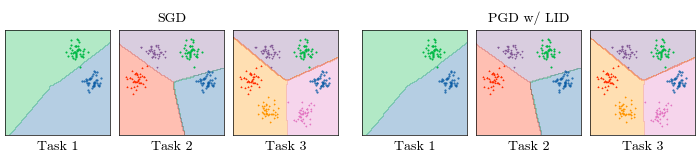

In [29]:
torch.manual_seed(0)
hidden_dim = 32
model = torch.nn.Sequential(
    torch.nn.Linear(2, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, 6),
)
sgd_models = []
trainer = SimpleTrainer(model)
for task, val_task in zip(train_tasks, val_tasks):
    trainer.train(
        task, val_task, n_epochs=10, batchsize=64, learning_rate=0.1, weight_decay=0.1
    )
    trainer.test(test_tasks)
    sgd_models.append(trainer.model)

plot_results(sgd_models, sgd_models, test_tasks)

In [30]:
l2_reg = L2Regulariser(lmbd=0.01)
ubias_reg = UnbiasRegulariser(
    lmbd=0.05, unbias_domain=[X.min(dim=0).values, X.max(dim=0).values]
)
regulariser = MultiRegulariser([l2_reg, ubias_reg])

interval_trainer = IntervalTrainer(
    model,
    min_acc_increment=0.1,
    min_acc_limit=0.9,
    n_iters=100,
    primal_learning_rate=0.5,
    dual_learning_rate=0.1,
    checkpoint=5,
    paradigm="CIL",
    projection_strategy="best_loss",
)

certified_models = []

for task, val_task, test_task in zip(train_tasks, val_tasks, test_tasks):
    interval_trainer.train(
        task,
        val_task,
        n_epochs=10,
        batchsize=64,
        learning_rate=0.1,
        regulariser=regulariser,
        val_freq=1,
    )
    interval_trainer.compute_rashomon_set(test_task)
    interval_trainer.test(test_tasks)
    certified_models.append(interval_trainer.model)

Training Epochs:   0%|          | 0/5 [00:00<?, ?it/s, val_loss=1.4637, val_acc=0.5000, proj=None, progress=0.07]

Training Epochs: 100%|██████████| 5/5 [00:00<00:00, 10.64it/s, val_loss=0.2332, val_acc=1.0000, proj=None, progress=0.93]


Initial acc constraint violation: -0.0998 (Positive = violated)
Number of model parameters: 294
Computing Rashomon set with min acc limit: 0.90
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 100/100 [00:01<00:00, 87.28it/s, size=621.73, obj=2.100, min_soft_acc=0.842]


Final bbox:  Obj=2.11,  Size=621.73,  Min acc hard=0.86,  Min acc soft=0.84
Computing final certificates over 256 samples
Checkpointed every 5 iterations for a total of 20 checkpoints
Checkpoints sizes: ['6.11', '12.38', '21.25', '33.12', '44.77', '63.13', '89.34', '124.34', '167.56', '207.64', '249.02', '284.00', '329.93', '376.10', '422.38', '469.79', '516.58', '563.71', '598.94', '621.73']
Checkpoint certificates: ['0.89', '0.95', '0.99', '0.96', '0.95', '0.94', '0.94', '0.83', '0.83', '0.89', '0.87', '0.90', '0.88', '0.88', '0.88', '0.89', '0.88', '0.85', '0.85', '0.86']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.2215, 1.0), (1.9866, 0.11), (1.2891, 0.21)] (Avg: (1.1657, 0.4400))


...

Final bbox:  Obj=0.04,  Size=13.11,  Min acc hard=0.92,  Min acc soft=0.90
Computing final certificates over 256 samples
Checkpointed every 5 iterations for a total of 20 checkpoints
Checkpoints sizes: ['4.17', '6.15', '8.57', '11.22', '12.72', '13.27', '13.64', '12.30', '12.85', '12.26', '12.07', '12.38', '12.75', '13.26', '13.59', '14.07', '13.60', '12.99', '13.02', '13.11']
Checkpoint certificates: ['0.81', '0.95', '0.95', '0.97', '0.95', '0.95', '0.87', '0.94', '0.90', '0.93', '0.93', '0.88', '0.90', '0.89', '0.92', '0.92', '0.92', '0.92', '0.89', '0.92']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.4567, 1.0), (0.2102, 0.99), (1.0528, 0.52)] (Avg: (0.5732, 0.8367))


Training Epochs: 100%|██████████| 5/5 [00:00<00:00,  6.29it/s, val_loss=0.5410, val_acc=1.0000, proj=1, progress=0.93]


Initial acc constraint violation: -0.1004 (Positive = violated)
Computing Rashomon set within outer box of size: 6.15
Number of model parameters: 294
Computing Rashomon set with min acc limit: 0.89
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|██████████| 100/100 [00:01<00:00, 93.60it/s, size=4.96, obj=0.017, min_soft_acc=0.884]


Final bbox:  Obj=0.02,  Size=4.96,  Min acc hard=0.94,  Min acc soft=0.89
Computing final certificates over 256 samples
Checkpointed every 5 iterations for a total of 20 checkpoints
Checkpoints sizes: ['2.22', '3.13', '3.84', '3.94', '4.16', '4.31', '4.48', '4.60', '4.71', '4.80', '4.89', '4.86', '4.91', '4.92', '4.94', '4.93', '4.95', '4.95', '4.96', '4.96']
Checkpoint certificates: ['0.94', '0.97', '0.96', '0.97', '0.97', '0.97', '0.97', '0.96', '0.97', '0.97', '0.95', '0.96', '0.96', '0.93', '0.93', '0.94', '0.94', '0.94', '0.93', '0.94']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.4533, 1.0), (0.4122, 0.99), (0.5126, 0.99)] (Avg: (0.4594, 0.9933))


Test Results: [(1.6428, 0.0), (1.1181, 0.49), (0.2018, 1.0)] (Avg: (0.9876, 0.4967))
Test Results: [(0.4533, 1.0), (0.4122, 0.99), (0.5126, 0.99)] (Avg: (0.4594, 0.9933))


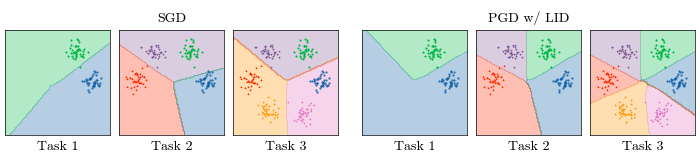

In [31]:
trainer.test(test_tasks)
interval_trainer.test(test_tasks)
plot_results(sgd_models, certified_models, test_tasks)